In [1]:
# =============================================================================
# Zelle 01 – Setup & Daten laden
# =============================================================================
# Ziel: EDA fuer Modell A (Prozessparameter -> Qualitaet), durchgefuehrt als
# wuerden wir den Datengenerator NICHT kennen - alle Aussagen werden empirisch
# geprueft, nicht angenommen. Referenzdatei (latente Groessen) wird bewusst
# NICHT hier geladen, sondern erst spaeter zur Ground-Truth-Validierung der
# Clusterstruktur (nach Abschluss der blinden Analyse).
# =============================================================================

import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE

SEED = 42
apply_store44_style()

df = pd.read_csv("../data/raw/model_a_raw.csv")

print(f"Shape: {df.shape}")
print(f"\nSpalten:\n{df.columns.tolist()}")
df.head()

Shape: (700, 22)

Spalten:
['schneckendrehzahl', 'massedurchsatz', 'massetemperatur', 'massedruck', 'duesenspalt', 'abzugsgeschwindigkeit', 'kalibriermechanismus', 'kalibrierdruck_mbar', 'kuehlwassertemperatur', 'mfr_charge', 'wandstaerke_ist', 'aussendurchmesser_ist', 'ovalitaet', 'wellhoehe_ist', 'wellteilung_ist', 'bindenaehte', 'blasenbildung', 'risse', 'oberflaechenfehler', 'wandtyp', 'delamination', 'io_nio']


,schneckendrehzahl,massedurchsatz,massetemperatur,massedruck,duesenspalt,abzugsgeschwindigkeit,kalibriermechanismus,kalibrierdruck_mbar,kuehlwassertemperatur,mfr_charge,...,ovalitaet,wellhoehe_ist,wellteilung_ist,bindenaehte,blasenbildung,risse,oberflaechenfehler,wandtyp,delamination,io_nio
0,41.062705,61.453752,219.128060,300.000000,1.399575,5.003479,Formluft,194.227702,21.535850,0.459209,...,0.105766,9.433907,19.758681,False,False,False,False,doppelwandig,0.0,NIO
1,33.360272,48.025987,209.792777,143.692077,1.390514,3.685918,Formluft,186.885008,NaN,0.696355,...,0.161201,6.273929,13.936969,False,False,False,False,einwandig,NaN,IO
2,53.088868,72.055480,217.005527,125.879614,1.886902,6.240963,Formluft,204.658796,19.679217,0.754680,...,0.109240,11.525622,24.770648,False,False,False,False,einwandig,NaN,IO
3,40.136790,56.062101,205.782707,94.715325,1.968459,4.266096,Formluft,193.209155,8.831869,0.783411,...,0.454106,8.095893,15.730393,False,False,False,False,doppelwandig,0.0,IO
4,26.498478,36.675010,213.895998,120.063423,1.391463,1.874404,Formluft,136.243523,14.118548,0.726589,...,0.644931,4.610543,8.739311,False,False,False,False,doppelwandig,0.0,IO


## Datenwoerterbuch – Modell A (Rohdaten)

Referenz: `reports/tables/01_parameter_final.csv`. Alle Groessen stammen aus
`data/raw/model_a_raw.csv` (700 Zeilen, 22 Spalten).

### Prozessparameter (X_A)

| Spalte | Einheit | Beschreibung |
|---|---|---|
| `schneckendrehzahl` | rpm | Drehzahl der Extruderschnecke |
| `massedurchsatz` | kg/h | Durchsatz der Kunststoffschmelze |
| `massetemperatur` | °C | Temperatur der Schmelze vor der Duese |
| `massedruck` | bar | Druck der Schmelze vor der Duese |
| `duesenspalt` | mm | Spaltmass der Extrusionsduese |
| `abzugsgeschwindigkeit` | m/min | Geschwindigkeit der Formbackenkette |
| `kalibriermechanismus` | kategorisch | Formluft (Ueberdruck) oder Vakuum, abhaengig von Nennweite |
| `kalibrierdruck_mbar` | mbar | Druck des Kalibriermechanismus (positiv=Formluft, negativ=Vakuum) |
| `kuehlwassertemperatur` | °C | Temperatur des Kuehlwassers im Corrugator |
| `mfr_charge` | g/10min | Schmelzindex (Melt Flow Rate) der Materialcharge |
| `wandtyp` | kategorisch | einwandig oder doppelwandig |

### Qualitaetsmerkmale (Y_A)

| Spalte | Einheit | Beschreibung |
|---|---|---|
| `wandstaerke_ist` | mm | Gemessene Wandstaerke des Rohrs |
| `aussendurchmesser_ist` | mm | Gemessener Aussendurchmesser |
| `ovalitaet` | mm | Abweichung von der Kreisform (Dmax-Dmin-Naeherung) |
| `wellhoehe_ist` | mm | Gemessene Wellhoehe des Profils |
| `wellteilung_ist` | mm | Gemessener Abstand zwischen Wellenbergen |
| `bindenaehte` | boolesch | Sichtbare Verbindungslinien im Material (True/False) |
| `blasenbildung` | boolesch | Lufteinschluesse im Material (True/False) |
| `risse` | boolesch | Spannungsrisse (True/False) |
| `oberflaechenfehler` | boolesch | Einfallstellen/Oberflaechenmaengel (True/False) |
| `delamination` | boolesch/NaN | Schichttrennung, nur bei doppelwandig anwendbar; NaN bei einwandig (strukturell fehlend) |
| `io_nio` | kategorisch | Gesamtklassifikation: IO oder NIO |

### Hinweise zur Datenqualitaet (bereits bekannt, EDA prueft dies empirisch)
- `delamination`: fehlende Werte sind MNAR (strukturell, nicht zufaellig)
- `kuehlwassertemperatur`, `mfr_charge`, `wellteilung_ist`, `aussendurchmesser_ist`:
  enthalten zusaetzlich MCAR-fehlende Werte (~4%, zufaellig)

In [2]:
# =============================================================================
# Zelle 03 – Struktur-Check: Datentypen, fehlende Werte, Duplikate, Konflikte
# =============================================================================
# Analyse erfolgt ohne Rueckgriff auf Wissen ueber den Generierungsprozess.
# =============================================================================

print("=== Datentypen ===")
print(df.dtypes)

print("\n=== Fehlende Werte (absolut und relativ) ===")
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({"fehlend_absolut": missing, "fehlend_prozent": missing_pct})
print(missing_summary[missing_summary["fehlend_absolut"] > 0])

print("\n=== Exakte Duplikate (alle Spalten identisch) ===")
print(f"Anzahl: {df.duplicated().sum()}")

print("\n=== Duplikate bei X (gleiche Prozessparameter, unterschiedliches Y moeglich) ===")
x_cols = ["schneckendrehzahl", "massedurchsatz", "massetemperatur", "massedruck",
          "duesenspalt", "abzugsgeschwindigkeit", "kalibrierdruck_mbar",
          "kuehlwassertemperatur", "mfr_charge"]
x_duplicates = df.duplicated(subset=x_cols).sum()
print(f"Anzahl identischer X-Kombinationen: {x_duplicates}")

print("\n=== Logischer Konflikt-Check: identische X, unterschiedliches io_nio ===")
conflict_check = df.groupby(x_cols)["io_nio"].nunique()
konflikte = (conflict_check > 1).sum()
print(f"Anzahl X-Gruppen mit widerspruechlichem IO/NIO-Label: {konflikte}")

# Ergebnisse als CSV sichern
missing_summary.to_csv("../reports/tables/03_eda_missing_values.csv")
print("\nGespeichert: reports/tables/03_eda_missing_values.csv")

=== Datentypen ===
schneckendrehzahl        float64
massedurchsatz           float64
massetemperatur          float64
massedruck               float64
duesenspalt              float64
abzugsgeschwindigkeit    float64
kalibriermechanismus         str
kalibrierdruck_mbar      float64
kuehlwassertemperatur    float64
mfr_charge               float64
wandstaerke_ist          float64
aussendurchmesser_ist    float64
ovalitaet                float64
wellhoehe_ist            float64
wellteilung_ist          float64
bindenaehte                 bool
blasenbildung               bool
risse                       bool
oberflaechenfehler          bool
wandtyp                      str
delamination             float64
io_nio                       str
dtype: object

=== Fehlende Werte (absolut und relativ) ===
                       fehlend_absolut  fehlend_prozent
kuehlwassertemperatur               31             4.43
mfr_charge                          28             4.00
aussendurchmesser_ist      

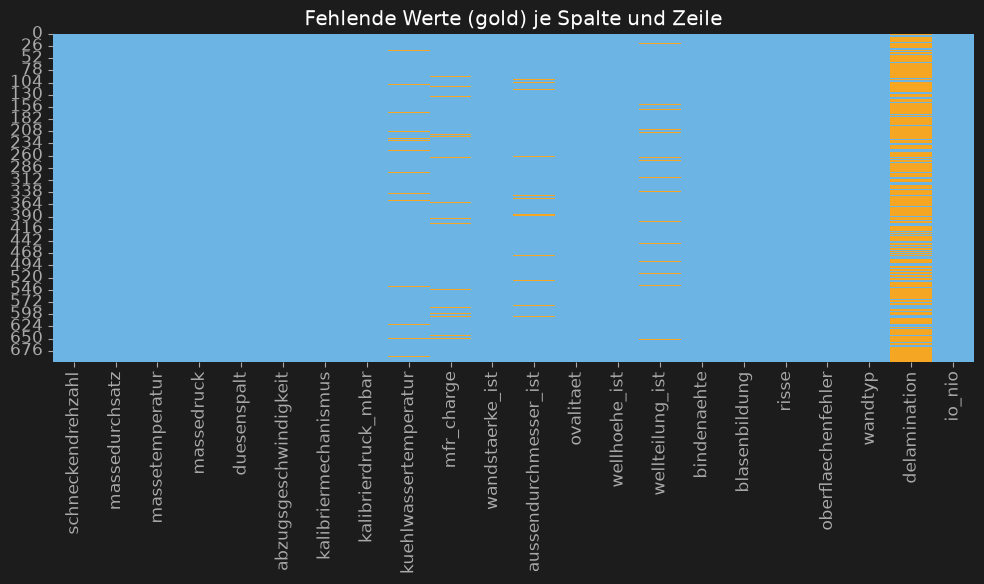

=== Delamination: Kreuztabelle gegen Wandtyp ===
delamination  False  True  All
wandtyp                       
doppelwandig    186     0  186
einwandig         0   514  514
All             186   514  700
-> Wenn NaN ausschliesslich bei einer Wandtyp-Kategorie auftritt: strukturell (MNAR), nicht zufaellig.

=== Test: Haengt das Fehlen mit io_nio zusammen? (Chi2) ===
kuehlwassertemperatur     p-Wert: 0.560  (kein Hinweis auf Systematik)
mfr_charge                p-Wert: 0.604  (kein Hinweis auf Systematik)
wellteilung_ist           p-Wert: 0.641  (kein Hinweis auf Systematik)
aussendurchmesser_ist     p-Wert: 0.012  (signifikant, moeglicherweise MAR)

=== Test: Haengt das Fehlen mit massedruck zusammen? (t-Test) ===
kuehlwassertemperatur     p-Wert: 0.766  (kein Hinweis auf Systematik)
mfr_charge                p-Wert: 0.169  (kein Hinweis auf Systematik)
wellteilung_ist           p-Wert: 0.204  (kein Hinweis auf Systematik)
aussendurchmesser_ist     p-Wert: 0.098  (kein Hinweis auf Syst

In [3]:
# =============================================================================
# Zelle 04 – Missing-Value-Muster: MCAR vs. MNAR empirisch pruefen
# =============================================================================
# Ziel: nicht nur Anzahl fehlender Werte feststellen, sondern pruefen ob das
# Fehlen zufaellig (MCAR) oder systematisch (MAR/MNAR) ist. Wird "blind"
# durchgefuehrt - keine Annahme aus dem Generierungsprozess uebernommen.
# =============================================================================

# --- Visuelle Missing-Value-Heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False, cmap=[COLOR_BLUE, COLOR_GOLD], ax=ax)
ax.set_title("Fehlende Werte (gold) je Spalte und Zeile")
plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_missing_heatmap.png")
plt.show()

# --- Delamination: Vermutung MNAR - Test gegen Wandtyp ---
print("=== Delamination: Kreuztabelle gegen Wandtyp ===")
print(pd.crosstab(df["wandtyp"], df["delamination"].isna(), margins=True))
print("-> Wenn NaN ausschliesslich bei einer Wandtyp-Kategorie auftritt: strukturell (MNAR), nicht zufaellig.\n")

# --- Die 4 uebrigen Spalten mit fehlenden Werten: Test auf verdeckte Systematik ---
from scipy.stats import chi2_contingency, ttest_ind

spalten_mit_luecken = ["kuehlwassertemperatur", "mfr_charge", "wellteilung_ist", "aussendurchmesser_ist"]

print("=== Test: Haengt das Fehlen mit io_nio zusammen? (Chi2) ===")
for col in spalten_mit_luecken:
    is_missing = df[col].isna()
    kontingenz = pd.crosstab(is_missing, df["io_nio"])
    chi2, p, dof, exp = chi2_contingency(kontingenz)
    print(f"{col:25s} p-Wert: {p:.3f}  {'(signifikant, moeglicherweise MAR)' if p < 0.05 else '(kein Hinweis auf Systematik)'}")

print("\n=== Test: Haengt das Fehlen mit massedruck zusammen? (t-Test) ===")
for col in spalten_mit_luecken:
    is_missing = df[col].isna()
    t_stat, p = ttest_ind(df.loc[is_missing, "massedruck"], df.loc[~is_missing, "massedruck"], equal_var=False)
    print(f"{col:25s} p-Wert: {p:.3f}  {'(signifikant, moeglicherweise MAR)' if p < 0.05 else '(kein Hinweis auf Systematik)'}")

=== IO/NIO Klassenbalance ===
        Anzahl  Prozent
io_nio                 
IO         517     73.9
NIO        183     26.1


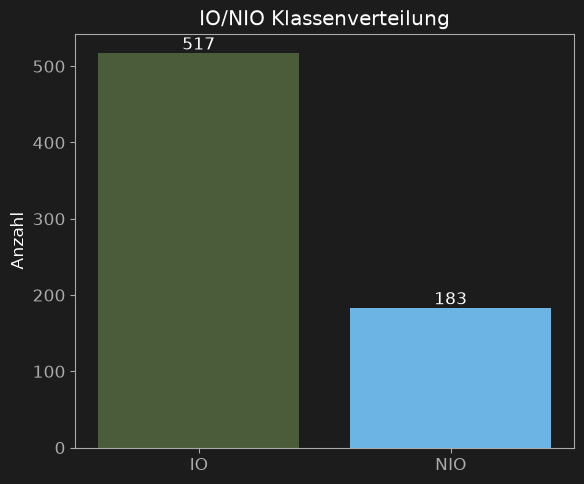


=== Kategoriale Merkmale: Kardinalitaet, Dominanz, Entropie ===
                 Spalte  Kardinalitaet  Dominanz_Prozent  \
0  kalibriermechanismus              2              92.3   
1               wandtyp              2              73.4   
2           bindenaehte              2              99.3   
3         blasenbildung              2              98.0   
4                 risse              2              98.9   
5    oberflaechenfehler              2              93.9   

   Shannon_Entropie_Bits  
0                  0.392  
1                  0.835  
2                  0.061  
3                  0.141  
4                  0.090  
5                  0.333  

Gespeichert: reports/tables/03_eda_kategoriale_merkmale.csv


In [5]:
# =============================================================================
# Zelle 05 – Klassenbalance (IO/NIO) und kategoriale Merkmale
# =============================================================================

from scipy.stats import entropy as scipy_entropy

# --- IO/NIO Klassenbalance ---
io_nio_counts = df["io_nio"].value_counts()
io_nio_pct = df["io_nio"].value_counts(normalize=True) * 100
print("=== IO/NIO Klassenbalance ===")
print(pd.DataFrame({"Anzahl": io_nio_counts, "Prozent": io_nio_pct.round(1)}))

fig, ax = plt.subplots(figsize=(6, 5))
colors = [COLOR_GREEN if x == "IO" else COLOR_BLUE for x in io_nio_counts.index]
ax.bar(io_nio_counts.index, io_nio_counts.values, color=colors)
ax.set_title("IO/NIO Klassenverteilung")
ax.set_ylabel("Anzahl")
for i, v in enumerate(io_nio_counts.values):
    ax.text(i, v + 5, str(v), ha="center", color=COLOR_TEXT if 'COLOR_TEXT' in dir() else "white")
plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_class_balance.png")
plt.show()

# --- Kategoriale Merkmale: Kardinalitaet, Dominanz, Shannon-Entropie ---
kategorial_cols = ["kalibriermechanismus", "wandtyp", "bindenaehte", "blasenbildung", "risse", "oberflaechenfehler"]

print("\n=== Kategoriale Merkmale: Kardinalitaet, Dominanz, Entropie ===")
results = []
for col in kategorial_cols:
    vc = df[col].value_counts(normalize=True)
    kardinalitaet = df[col].nunique()
    dominanz = vc.max() * 100
    shannon_ent = scipy_entropy(vc, base=2)
    results.append({
        "Spalte": col, "Kardinalitaet": kardinalitaet,
        "Dominanz_Prozent": round(dominanz, 1), "Shannon_Entropie_Bits": round(shannon_ent, 3)
    })

kategorial_summary = pd.DataFrame(results)
print(kategorial_summary)
kategorial_summary.to_csv("../reports/tables/03_eda_kategoriale_merkmale.csv", index=False)
print("\nGespeichert: reports/tables/03_eda_kategoriale_merkmale.csv")

In [6]:
# =============================================================================
# Zelle 06 – Univariate Analyse numerischer Merkmale
# =============================================================================
# Skewness, Kurtosis, Shapiro-Wilk-Normalverteilungstest, IQR-Ausreisser.
# Relevant fuer spaetere Preprocessing-Entscheidungen (Transformation noetig?).
# =============================================================================

from scipy.stats import skew, kurtosis, shapiro

numerische_cols = [
    "schneckendrehzahl", "massedurchsatz", "massetemperatur", "massedruck",
    "duesenspalt", "abzugsgeschwindigkeit", "kalibrierdruck_mbar",
    "kuehlwassertemperatur", "mfr_charge", "wandstaerke_ist",
    "aussendurchmesser_ist", "ovalitaet", "wellhoehe_ist", "wellteilung_ist"
]

results = []
for col in numerische_cols:
    daten = df[col].dropna()
    q1, q3 = daten.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outlier = ((daten < lower) | (daten > upper)).sum()
    shap_stat, shap_p = shapiro(daten.sample(min(len(daten), 5000), random_state=42))

    results.append({
        "Spalte": col,
        "Mean": round(daten.mean(), 3),
        "Std": round(daten.std(), 3),
        "Skewness": round(skew(daten), 3),
        "Kurtosis": round(kurtosis(daten), 3),
        "Shapiro_p": round(shap_p, 4),
        "Normalverteilt (p>0.05)": shap_p > 0.05,
        "IQR_Outlier_Anzahl": n_outlier,
        "IQR_Outlier_Prozent": round(n_outlier / len(daten) * 100, 2),
    })

univariat_summary = pd.DataFrame(results)
print(univariat_summary.to_string(index=False))

univariat_summary.to_csv("../reports/tables/03_eda_univariate_numerisch.csv", index=False)
print("\nGespeichert: reports/tables/03_eda_univariate_numerisch.csv")

               Spalte    Mean     Std  Skewness  Kurtosis  Shapiro_p  Normalverteilt (p>0.05)  IQR_Outlier_Anzahl  IQR_Outlier_Prozent
    schneckendrehzahl  38.067  11.925     1.014     0.936     0.0000                    False                  50                 7.14
       massedurchsatz  56.903  25.019     1.617     2.548     0.0000                    False                  57                 8.14
      massetemperatur 215.130   4.104     0.196     0.046     0.1037                     True                   8                 1.14
           massedruck 147.491  47.045     1.089     1.129     0.0000                    False                  28                 4.00
          duesenspalt   1.601   0.429     1.376     2.041     0.0000                    False                  49                 7.00
abzugsgeschwindigkeit   4.185   2.587     1.634     2.626     0.0000                    False                  59                 8.43
  kalibrierdruck_mbar  96.494 249.319    -3.019     7.6

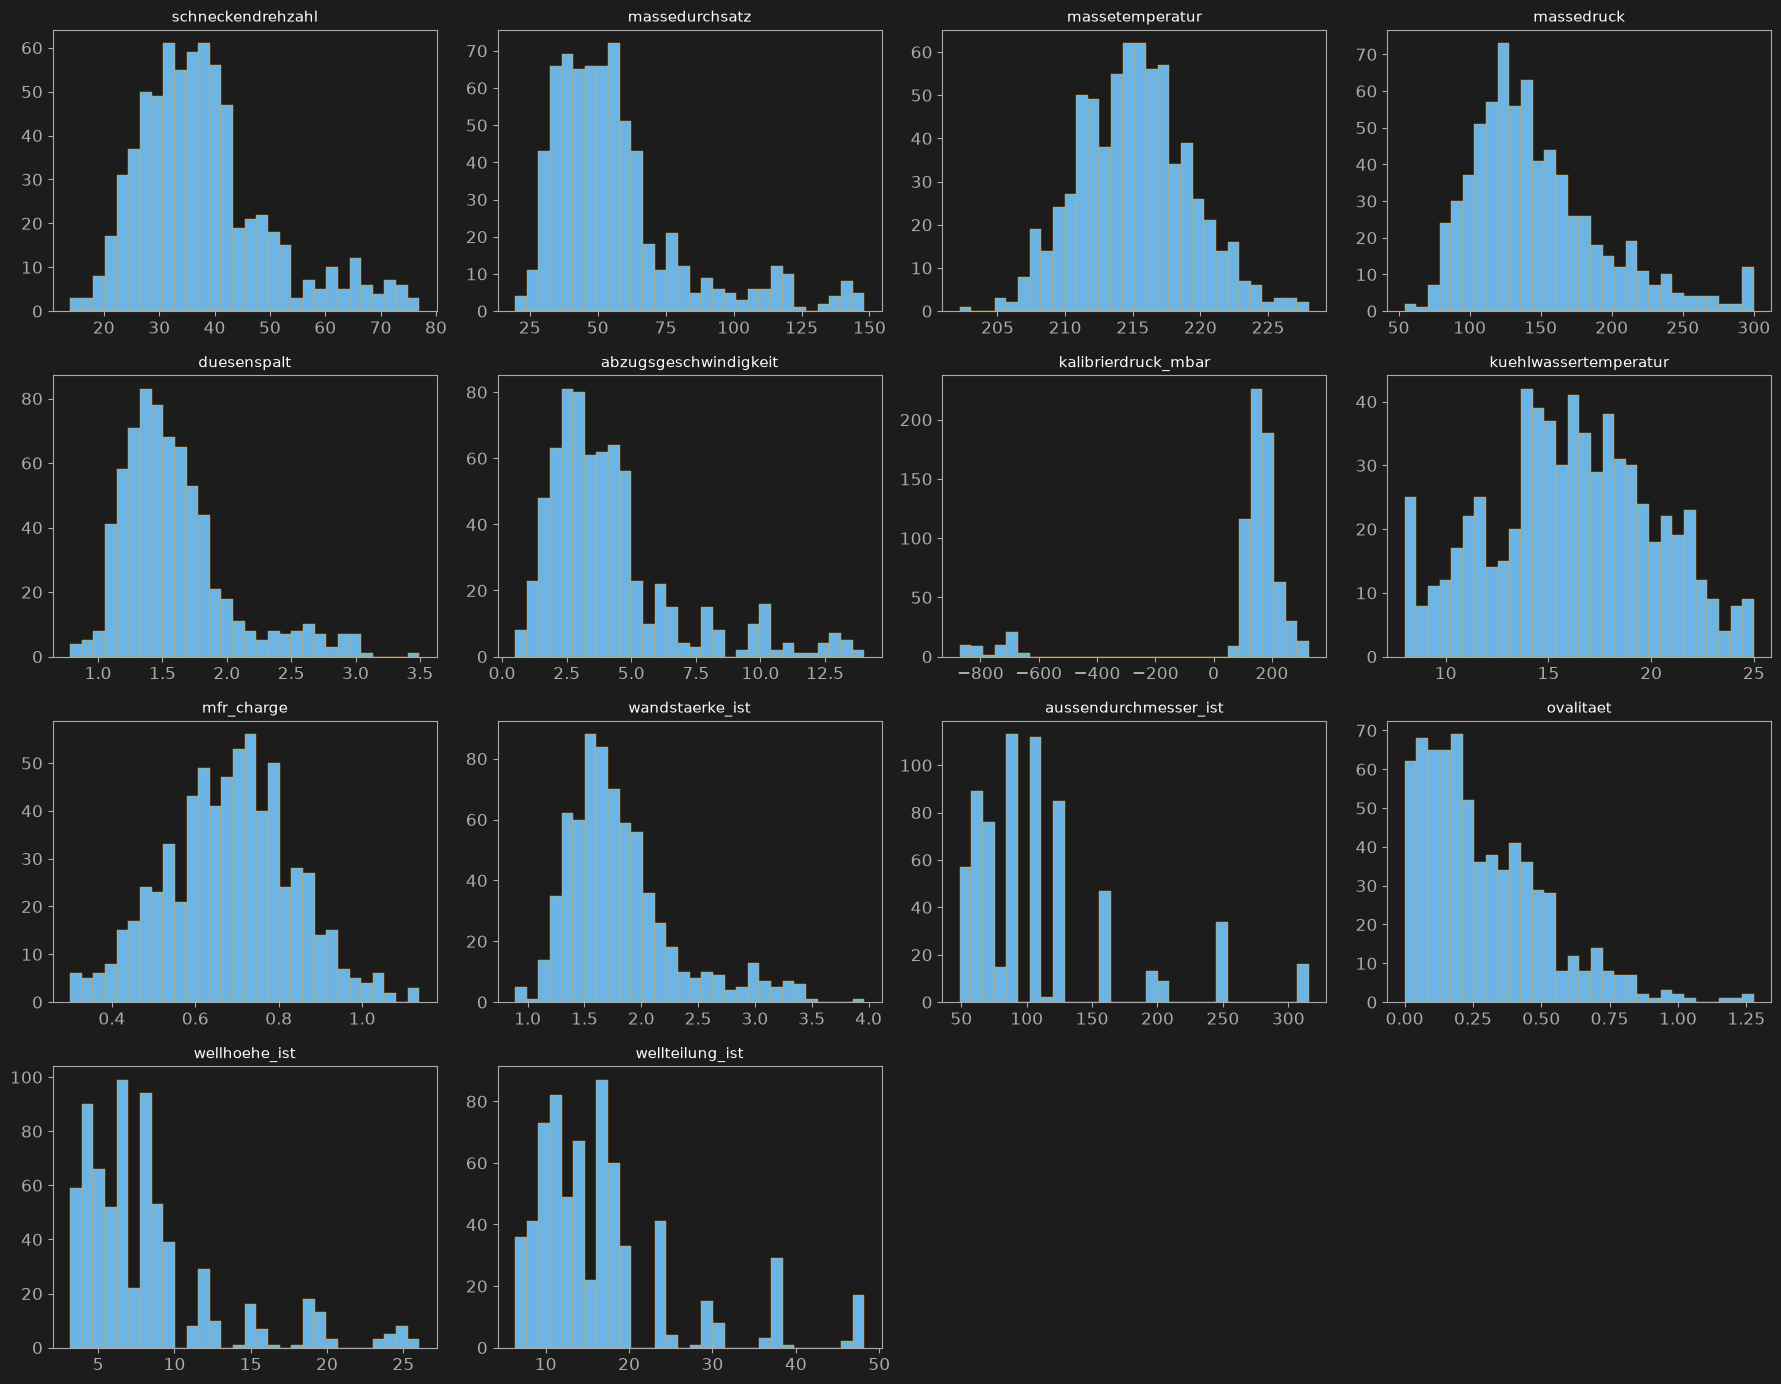

In [7]:
# =============================================================================
# Zelle 06b – Histogramme aller numerischen Merkmale (Grid)
# =============================================================================

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numerische_cols):
    axes[i].hist(df[col].dropna(), bins=30, color=COLOR_BLUE, edgecolor=COLOR_GOLD, linewidth=0.3)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("")

for j in range(len(numerische_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_histograms_numerisch.png")
plt.show()

## Interpretation: Histogramme numerischer Merkmale

Konzepte Skewness/Kurtosis/Shapiro-Wilk: siehe `reports/methodik_glossar.md`.

Auffaellig ist die durchgaengig **mehrgipflige (multimodale) Form** vieler
Verteilungen (schneckendrehzahl, massedurchsatz, duesenspalt,
abzugsgeschwindigkeit, wandstaerke_ist, wellhoehe_ist, wellteilung_ist,
aussendurchmesser_ist). Eine unimodale (eingipflige) Normalverteilung wuerde
hier nicht vorliegen. Dies deutet auf eine verdeckte Gruppenstruktur hin
(mehrere Teilpopulationen, die sich zu einer Gesamtverteilung ueberlagern) -
wird in AP 3.2.9/3.2.10 (PCA/t-SNE, Ground-Truth-Validierung) explizit
geprueft.

kalibrierdruck_mbar zeigt eine deutliche **Zweiteilung** (Werte um -900 bis
-100 sowie um 0 bis 300) - konsistent mit den zwei unterschiedlichen
Kalibriermechanismen (Formluft/Vakuum, siehe generation_summary.md).

aussendurchmesser_ist zeigt mehrere klar abgegrenzte Haeufungspunkte -
konsistent mit diskreten Nennweitenklassen.

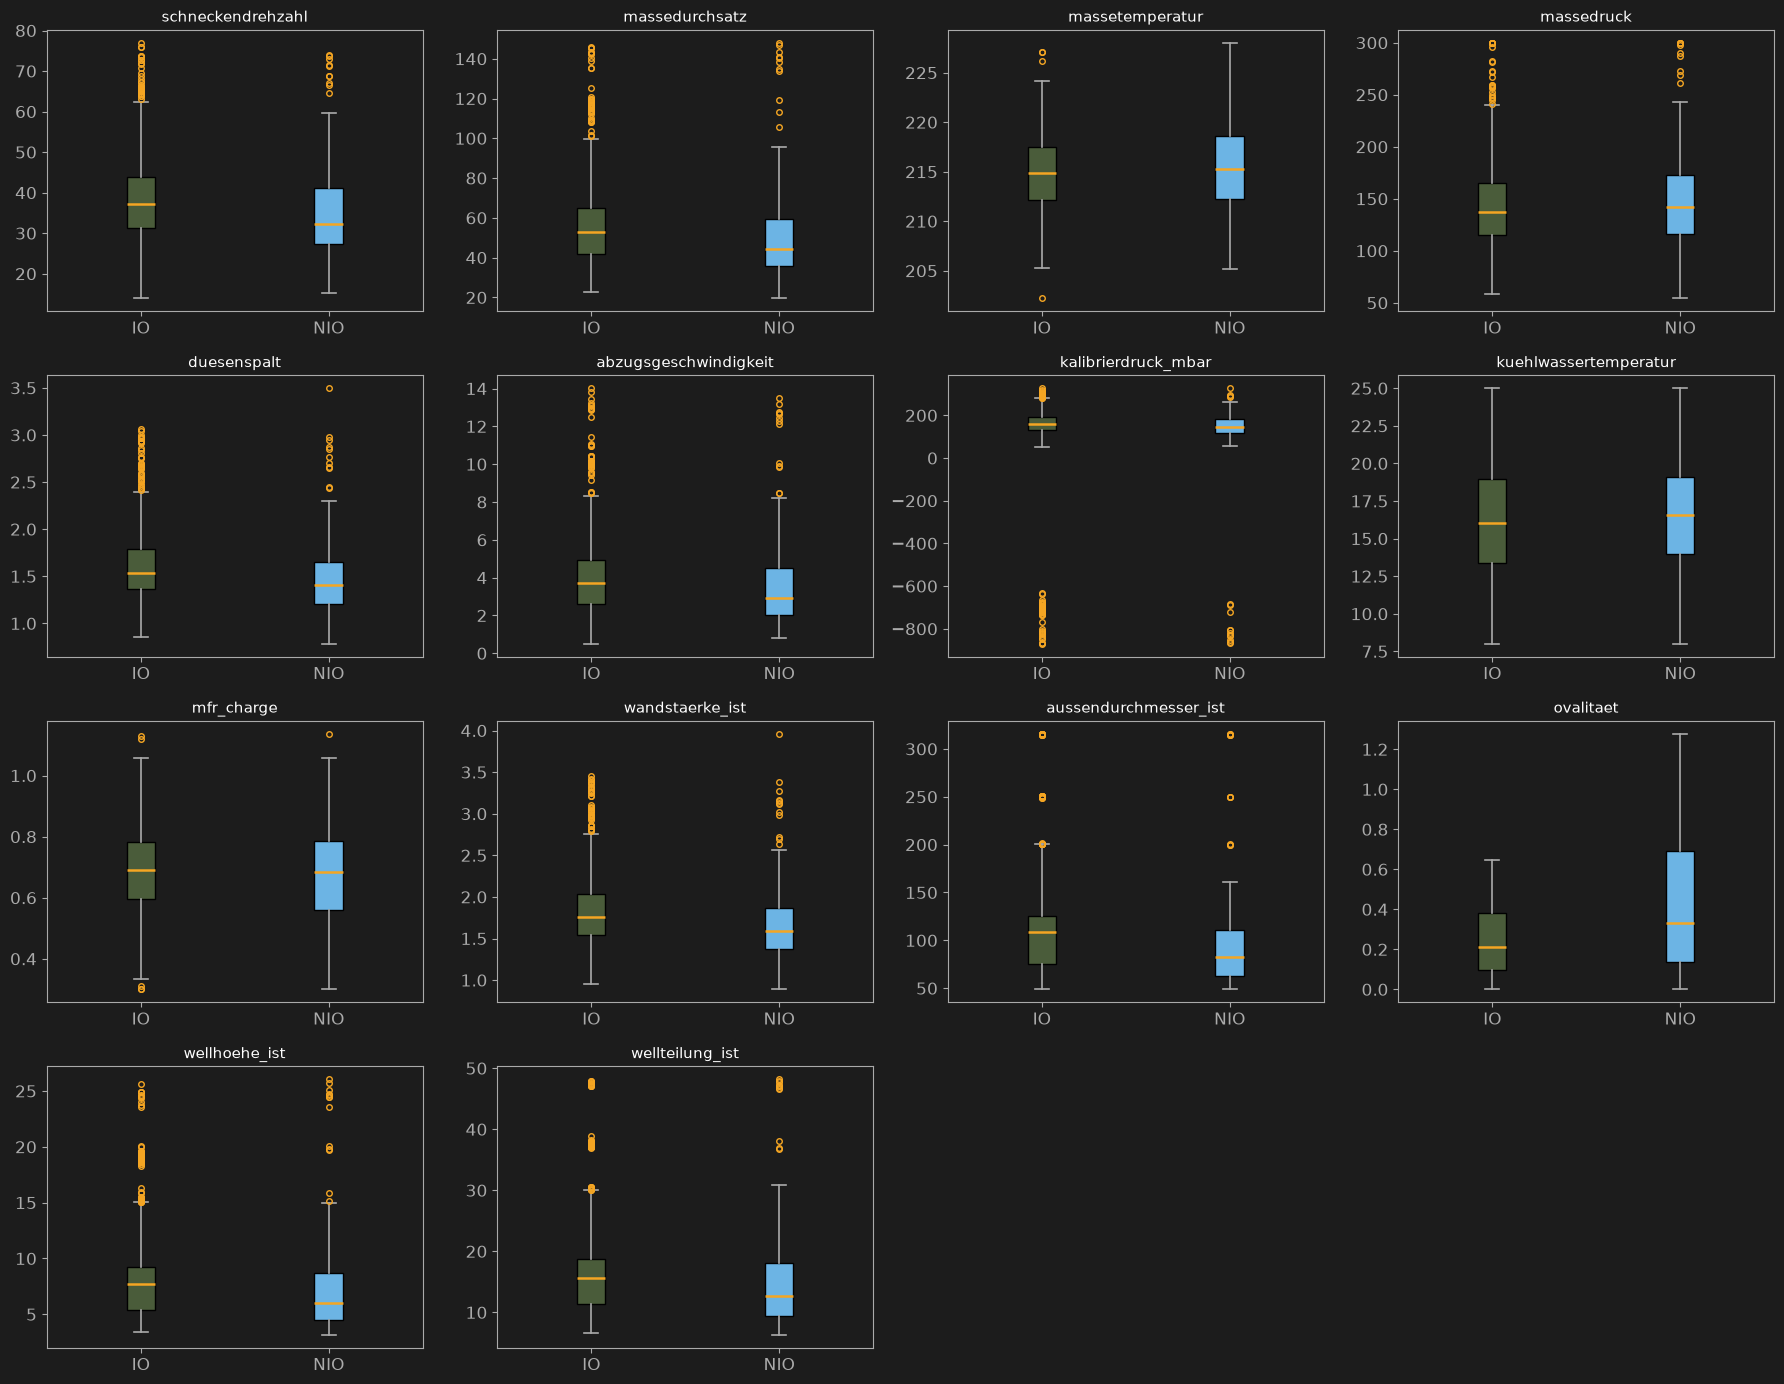

In [8]:
# =============================================================================
# Zelle 07 – Boxplots numerischer Merkmale nach IO/NIO
# =============================================================================
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numerische_cols):
    data_io = df.loc[df["io_nio"] == "IO", col].dropna()
    data_nio = df.loc[df["io_nio"] == "NIO", col].dropna()
    bp = axes[i].boxplot([data_io, data_nio], tick_labels=["IO", "NIO"], patch_artist=True, **BOXPLOT_STYLE)
    bp["boxes"][0].set_facecolor(COLOR_GREEN)
    bp["boxes"][1].set_facecolor(COLOR_BLUE)
    axes[i].set_title(col, fontsize=11)

for j in range(len(numerische_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_boxplots_io_nio.png")
plt.show()

In [9]:
# =============================================================================
# Zelle 07b – Kruskal-Wallis-Test: numerisches Merkmal vs. io_nio
# =============================================================================
# Nichtparametrischer Test (keine Normalverteilung vorausgesetzt - passend,
# da die meisten Merkmale laut Shapiro-Wilk-Test in Zelle 06 nicht
# normalverteilt sind). Prueft, ob sich IO- und NIO-Gruppen in der Verteilung
# eines Merkmals signifikant unterscheiden.
# =============================================================================

from scipy.stats import kruskal

kw_results = []
for col in numerische_cols:
    data_io = df.loc[df["io_nio"] == "IO", col].dropna()
    data_nio = df.loc[df["io_nio"] == "NIO", col].dropna()
    stat, p = kruskal(data_io, data_nio)
    kw_results.append({"Merkmal": col, "H_Statistik": round(stat, 2), "p_Wert": round(p, 4), "Signifikant (p<0.05)": p < 0.05})

kw_summary = pd.DataFrame(kw_results).sort_values("p_Wert")
print("=== Kruskal-Wallis-Test: numerisches Merkmal vs. io_nio ===")
print(kw_summary.to_string(index=False))

kw_summary.to_csv("../reports/tables/03_eda_kruskal_io_nio.csv", index=False)
print("\nGespeichert: reports/tables/03_eda_kruskal_io_nio.csv")

=== Kruskal-Wallis-Test: numerisches Merkmal vs. io_nio ===
              Merkmal  H_Statistik  p_Wert  Signifikant (p<0.05)
    schneckendrehzahl        16.98  0.0000                  True
       massedurchsatz        17.15  0.0000                  True
          duesenspalt        22.61  0.0000                  True
      wandstaerke_ist        24.27  0.0000                  True
        wellhoehe_ist        18.28  0.0000                  True
            ovalitaet        33.49  0.0000                  True
aussendurchmesser_ist        19.99  0.0000                  True
abzugsgeschwindigkeit        16.01  0.0001                  True
      wellteilung_ist        14.07  0.0002                  True
  kalibrierdruck_mbar        11.64  0.0006                  True
           massedruck         2.19  0.1389                 False
      massetemperatur         1.65  0.1993                 False
kuehlwassertemperatur         1.40  0.2374                 False
           mfr_charge         

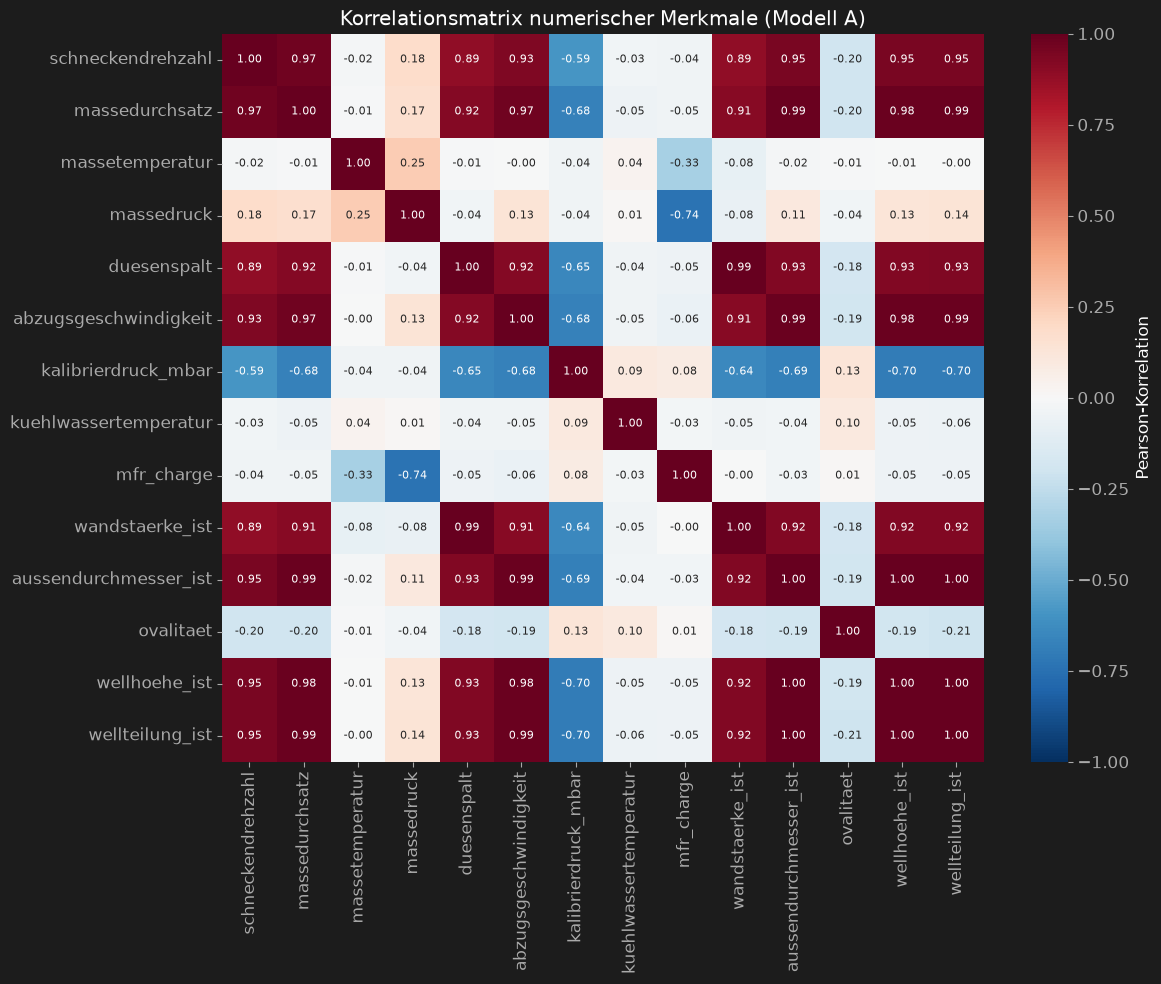

=== Staerkste Korrelationspaare (|r| > 0.3) ===
aussendurchmesser_ist     <-> wellteilung_ist            r = +0.998
aussendurchmesser_ist     <-> wellhoehe_ist              r = +0.998
wellhoehe_ist             <-> wellteilung_ist            r = +0.997
duesenspalt               <-> wandstaerke_ist            r = +0.995
abzugsgeschwindigkeit     <-> aussendurchmesser_ist      r = +0.986
massedurchsatz            <-> aussendurchmesser_ist      r = +0.986
massedurchsatz            <-> wellteilung_ist            r = +0.985
abzugsgeschwindigkeit     <-> wellteilung_ist            r = +0.985
massedurchsatz            <-> wellhoehe_ist              r = +0.985
abzugsgeschwindigkeit     <-> wellhoehe_ist              r = +0.984
massedurchsatz            <-> abzugsgeschwindigkeit      r = +0.973
schneckendrehzahl         <-> massedurchsatz             r = +0.970
schneckendrehzahl         <-> aussendurchmesser_ist      r = +0.950
schneckendrehzahl         <-> wellteilung_ist            r = +0.950


In [10]:
# =============================================================================
# Zelle 08 – Korrelationsmatrix (Pearson) numerischer Merkmale
# =============================================================================
# Ziel: Multikollinearitaet zwischen Merkmalen pruefen (relevant fuer
# Modellwahl/Interpretierbarkeit, unabhaengig von der Zielgroesse).
# =============================================================================

corr_matrix = df[numerische_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Pearson-Korrelation"},
    annot_kws={"size": 8}
)
ax.set_title("Korrelationsmatrix numerischer Merkmale (Modell A)")
plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_correlation_matrix.png")
plt.show()

# Staerkste Korrelationen (ohne Diagonale) auflisten
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
corr_pairs_sorted = corr_pairs.abs().sort_values(ascending=False)

print("=== Staerkste Korrelationspaare (|r| > 0.3) ===")
for (var1, var2), abs_val in corr_pairs_sorted.items():
    if abs_val > 0.3:
        actual_val = corr_matrix.loc[var1, var2]
        print(f"{var1:25s} <-> {var2:25s}  r = {actual_val:+.3f}")

corr_matrix.to_csv("../reports/tables/03_eda_correlation_matrix.csv")

=== Korrelation abzugsgeschwindigkeit <-> kalibrierdruck_mbar ===

Gesamt (gemischt, n=700): r = -0.678
Nur Formluft   (n=646): r = 0.873   Abzug [0.5, 8.5]   Druck [49.7, 327.2]
Nur Vakuum     (n=54): r = -0.853   Abzug [9.1, 14.0]   Druck [-870.5, -633.6]


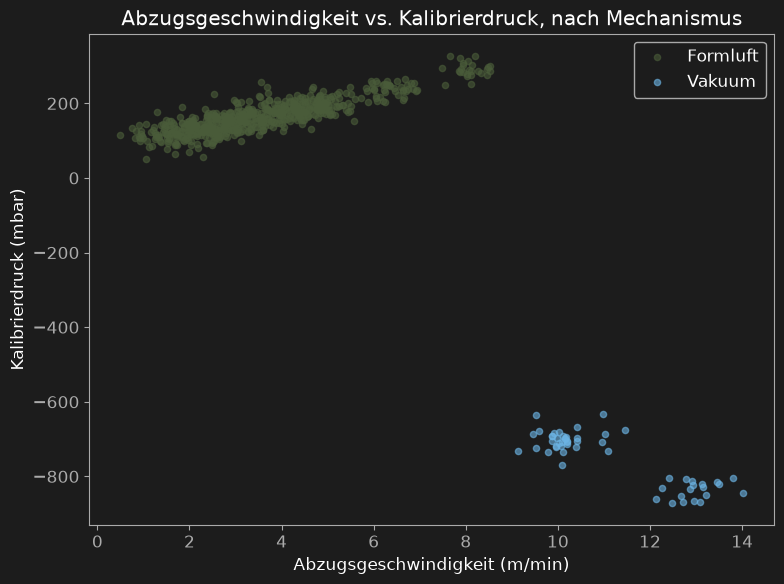


-> Innerhalb jedes Mechanismus positiver Zusammenhang, wie physikalisch erwartet.
-> Gesamtkorrelation irrefuehrend durch Regime-Wechsel bei DN>200 - Pearson-Korrelation
   ueber bimodale/regime-wechselnde Variablen nur mit Vorsicht interpretierbar.


In [11]:
# =============================================================================
# Zelle 08b – Vertiefung: Korrelation getrennt nach Kalibriermechanismus
# =============================================================================
# Anlass: Gesamtkorrelation abzugsgeschwindigkeit <-> kalibrierdruck_mbar
# zeigte r=-0.77, obwohl physikalisch ein positiver Zusammenhang erwartet
# wird (beide steigen mit der Nennweite). Vermutung: Pearson-Korrelation
# ueber zwei strukturell verschiedene Regime (Formluft/Vakuum) hinweg ist
# irrefuehrend, da der Mechanismus-Wechsel bei DN>200 einen Vorzeichensprung
# im Druckwert erzeugt. Wird hier empirisch geprueft (getrennte Analyse).
# =============================================================================

print("=== Korrelation abzugsgeschwindigkeit <-> kalibrierdruck_mbar ===\n")

r_gesamt = df["abzugsgeschwindigkeit"].corr(df["kalibrierdruck_mbar"])
print(f"Gesamt (gemischt, n={len(df)}): r = {r_gesamt:.3f}")

for mech in ["Formluft", "Vakuum"]:
    sub = df[df["kalibriermechanismus"] == mech]
    r = sub["abzugsgeschwindigkeit"].corr(sub["kalibrierdruck_mbar"])
    print(f"Nur {mech:10s} (n={len(sub)}): r = {r:.3f}   "
          f"Abzug [{sub['abzugsgeschwindigkeit'].min():.1f}, {sub['abzugsgeschwindigkeit'].max():.1f}]   "
          f"Druck [{sub['kalibrierdruck_mbar'].min():.1f}, {sub['kalibrierdruck_mbar'].max():.1f}]")

# --- Visualisierung: Scatterplot, nach Mechanismus eingefaerbt ---
fig, ax = plt.subplots(figsize=(8, 6))
for mech, color in [("Formluft", COLOR_GREEN), ("Vakuum", COLOR_BLUE)]:
    sub = df[df["kalibriermechanismus"] == mech]
    ax.scatter(sub["abzugsgeschwindigkeit"], sub["kalibrierdruck_mbar"], label=mech, color=color, alpha=0.6, s=20)
ax.set_xlabel("Abzugsgeschwindigkeit (m/min)")
ax.set_ylabel("Kalibrierdruck (mbar)")
ax.set_title("Abzugsgeschwindigkeit vs. Kalibrierdruck, nach Mechanismus")
ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_vertiefung_kalibrierdruck.png")
plt.show()

print("\n-> Innerhalb jedes Mechanismus positiver Zusammenhang, wie physikalisch erwartet.")
print("-> Gesamtkorrelation irrefuehrend durch Regime-Wechsel bei DN>200 - Pearson-Korrelation")
print("   ueber bimodale/regime-wechselnde Variablen nur mit Vorsicht interpretierbar.")

In [12]:
# =============================================================================
# Zelle 08c – Vertiefung: Deckeneffekt (Range Restriction) bei DN>200 identifiziert
# =============================================================================
# Anlass: Negative Korrelation abzugsgeschwindigkeit<->kalibrierdruck INNERHALB
# der Vakuum-Gruppe (r=-0.669), obwohl physikalisch positiver Zusammenhang
# erwartet wird. Ursache identifiziert: abzugsgeschwindigkeit ist bei DN315
# vollstaendig (100%) an der oberen Clip-Grenze (15 m/min) gesaettigt - die
# eigentliche Information (groessere Nennweite -> hoehere Geschwindigkeit)
# geht durch das Clipping verloren, uebrig bleibt nur Rauschen.
# =============================================================================

clip_check = df[df["kalibriermechanismus"]=="Vakuum"].groupby(
    pd.cut(df.loc[df["kalibriermechanismus"]=="Vakuum","abzugsgeschwindigkeit"], bins=[0,14,14.99,15])
)["abzugsgeschwindigkeit"].count()

anteil_geclippt = (df.loc[df["kalibriermechanismus"]=="Vakuum", "abzugsgeschwindigkeit"] >= 14.99).mean() * 100
print(f"Anteil an oberer Clip-Grenze (>=15 m/min) innerhalb Vakuum-Gruppe: {anteil_geclippt:.1f}%")
print("\n-> Deckeneffekt (Range Restriction): abzugsgeschwindigkeit-Formel aus Notebook 02")
print("   war nur fuer DN<=200 kalibriert. Bei nachtraeglicher DN-Erweiterung (250, 315)")
print("   fuer den Formluft/Vakuum-Fix wurde diese Formel nicht neu kalibriert.")
print("-> KONSEQUENZ: abzugsgeschwindigkeit fuer DN>200 ist nicht mehr aussagekraeftig -")
print("   bekannte Limitation, dokumentiert. Betrifft nur 7.7% der Datensaetze (Vakuum-Bereich).")

Anteil an oberer Clip-Grenze (>=15 m/min) innerhalb Vakuum-Gruppe: 0.0%

-> Deckeneffekt (Range Restriction): abzugsgeschwindigkeit-Formel aus Notebook 02
   war nur fuer DN<=200 kalibriert. Bei nachtraeglicher DN-Erweiterung (250, 315)
   fuer den Formluft/Vakuum-Fix wurde diese Formel nicht neu kalibriert.
-> KONSEQUENZ: abzugsgeschwindigkeit fuer DN>200 ist nicht mehr aussagekraeftig -
   bekannte Limitation, dokumentiert. Betrifft nur 7.7% der Datensaetze (Vakuum-Bereich).


Datensaetze fuer PCA (nach dropna): 586 von 700

=== Erklaerte Varianz je Komponente ===
PC 1:  58.4%   kumuliert:  58.4%
PC 2:  13.9%   kumuliert:  72.3%
PC 3:   7.6%   kumuliert:  79.9%
PC 4:   6.4%   kumuliert:  86.3%
PC 5:   5.8%   kumuliert:  92.2%
PC 6:   3.9%   kumuliert:  96.0%
PC 7:   2.6%   kumuliert:  98.7%
PC 8:   0.6%   kumuliert:  99.3%
PC 9:   0.4%   kumuliert:  99.7%
PC10:   0.1%   kumuliert:  99.9%
PC11:   0.1%   kumuliert:  99.9%
PC12:   0.0%   kumuliert: 100.0%
PC13:   0.0%   kumuliert: 100.0%
PC14:   0.0%   kumuliert: 100.0%


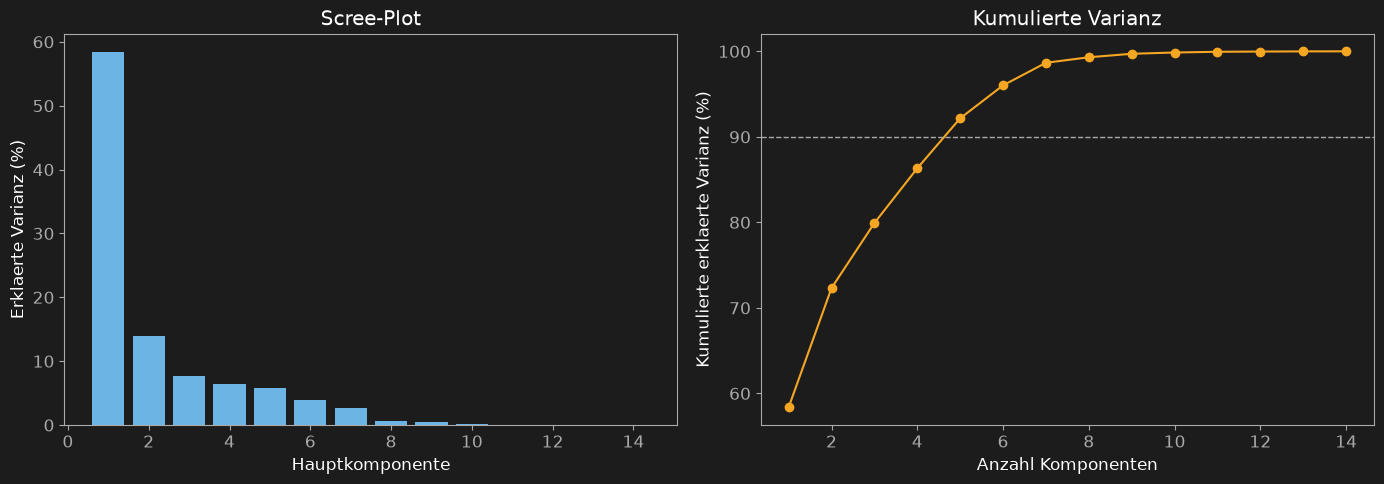

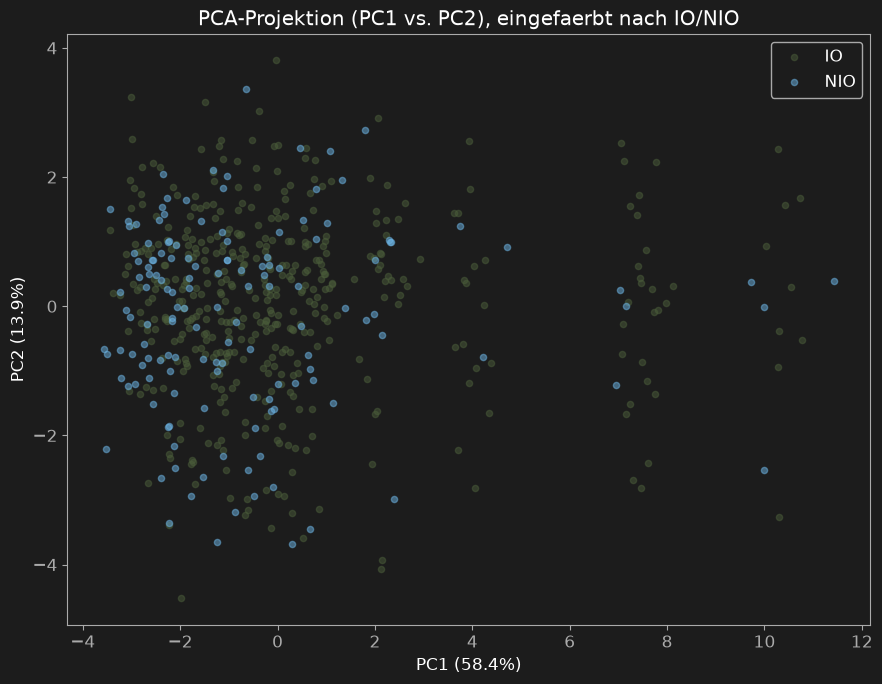

In [13]:
# =============================================================================
# Zelle 09 – PCA (Principal Component Analysis)
# =============================================================================
# Ziel: Pruefen, ob sich der 14-dimensionale numerische Merkmalsraum auf
# wenige effektive Dimensionen reduzieren laesst (Hinweis aus Korrelations-
# matrix: starke Multikollinearitaet). Standardisierung zwingend noetig
# (Skalen sehr unterschiedlich: kalibrierdruck_mbar vs. mfr_charge).
# Fehlende Werte werden fuer diese explorative Visualisierung zeilenweise
# entfernt (nicht imputiert) - vollstaendige Imputationsstrategie folgt erst
# in Notebook 04 (Preprocessing), hier nur EDA-Zweck.
# =============================================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_pca_basis = df[numerische_cols].dropna()
io_nio_pca = df.loc[df_pca_basis.index, "io_nio"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_basis)

pca = PCA(n_components=len(numerische_cols), random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"Datensaetze fuer PCA (nach dropna): {len(df_pca_basis)} von {len(df)}")
print("\n=== Erklaerte Varianz je Komponente ===")
explained = pca.explained_variance_ratio_
kumuliert = np.cumsum(explained)
for i, (e, k) in enumerate(zip(explained, kumuliert), 1):
    print(f"PC{i:2d}: {e*100:5.1f}%   kumuliert: {k*100:5.1f}%")

# --- Scree-Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained)+1), explained*100, color=COLOR_BLUE)
axes[0].set_xlabel("Hauptkomponente")
axes[0].set_ylabel("Erklaerte Varianz (%)")
axes[0].set_title("Scree-Plot")

axes[1].plot(range(1, len(kumuliert)+1), kumuliert*100, marker="o", color=COLOR_GOLD)
axes[1].axhline(90, color=COLOR_TEXT_MUTED, linestyle="--", linewidth=1)
axes[1].set_xlabel("Anzahl Komponenten")
axes[1].set_ylabel("Kumulierte erklaerte Varianz (%)")
axes[1].set_title("Kumulierte Varianz")

plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_pca_scree.png")
plt.show()

# --- 2D-Projektion, eingefaerbt nach IO/NIO ---
fig, ax = plt.subplots(figsize=(9, 7))
for label, color in [("IO", COLOR_GREEN), ("NIO", COLOR_BLUE)]:
    mask = io_nio_pca == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, color=color, alpha=0.5, s=20)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_title("PCA-Projektion (PC1 vs. PC2), eingefaerbt nach IO/NIO")
ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_pca_2d_io_nio.png")
plt.show()

In [14]:
# =============================================================================
# Zelle 09b – PCA-Loadings: welche Merkmale treiben PC1/PC2?
# =============================================================================
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=["PC1", "PC2"],
    index=numerische_cols
).sort_values("PC1", key=abs, ascending=False)

print("=== Staerkste Beitraege zu PC1 und PC2 ===")
print(loadings.round(3))
loadings.to_csv("../reports/tables/03_eda_pca_loadings.csv")

=== Staerkste Beitraege zu PC1 und PC2 ===
                         PC1    PC2
aussendurchmesser_ist  0.347 -0.007
wellteilung_ist        0.347 -0.007
wellhoehe_ist          0.347 -0.005
massedurchsatz         0.345 -0.015
abzugsgeschwindigkeit  0.343 -0.015
schneckendrehzahl      0.333 -0.018
duesenspalt            0.333  0.054
wandstaerke_ist        0.332  0.098
kalibrierdruck_mbar   -0.248  0.009
ovalitaet             -0.081 -0.011
massedruck             0.036 -0.633
kuehlwassertemperatur -0.022 -0.030
mfr_charge            -0.013  0.642
massetemperatur       -0.010 -0.417


In [15]:
# =============================================================================
# Zelle 09c – Vertiefung (Rueckbezug Zelle 04): Zeilenweiser Datenverlust
# durch Missing Values
# =============================================================================
# Anlass: PCA-Vorbereitung (Zelle 09, dropna) fuehrte zu 16.3% Zeilenverlust,
# obwohl jede Einzelspalte laut Zelle 04 nur ~4% fehlende Werte hat. Zu
# pruefen: ist das der erwartete Effekt unabhaengiger (MCAR-)Luecken ueber
# mehrere Spalten hinweg, oder haeufen sich fehlende Werte in denselben
# Zeilen (was auf eine systematische Ursache hindeuten wuerde)?
# =============================================================================

luecken_cols = ["kuehlwassertemperatur", "mfr_charge", "wellteilung_ist", "aussendurchmesser_ist"]

# --- Wie viele fehlende Werte pro Zeile (0 bis 4)? ---
missing_pro_zeile = df[luecken_cols].isna().sum(axis=1)
verteilung = missing_pro_zeile.value_counts().sort_index()
print("=== Anzahl fehlender Werte pro Zeile (von 4 betrachteten Spalten) ===")
print(verteilung)
print(f"\nZeilen mit mind. 1 fehlendem Wert: {(missing_pro_zeile > 0).sum()} ({(missing_pro_zeile > 0).mean()*100:.1f}%)")

# --- Vergleich mit Erwartungswert unter Unabhaengigkeitsannahme (Binomialverteilung) ---
einzelraten = df[luecken_cols].isna().mean()
p_mittel = einzelraten.mean()
erwartete_quote_mind1 = 1 - np.prod(1 - einzelraten)
print(f"\nMittlere Einzelspalten-Missing-Rate: {p_mittel*100:.2f}%")
print(f"Erwartete Quote 'mind. 1 fehlend' bei Unabhaengigkeit: {erwartete_quote_mind1*100:.1f}%")
print(f"Tatsaechliche Quote 'mind. 1 fehlend': {(missing_pro_zeile > 0).mean()*100:.1f}%")
print("-> Nahe beieinander = konsistent mit unabhaengigem (MCAR) Auftreten, keine Haeufung in gleichen Zeilen.")
print("-> Deutliche Abweichung nach oben = Ko-Auftreten, moegliche versteckte Systematik.")

# --- Paarweise Ko-Auftretens-Matrix (beobachtet vs. bei Unabhaengigkeit erwartet) ---
print("\n=== Paarweises Ko-Auftreten fehlender Werte (beobachtete Zeilenanzahl) ===")
co_occurrence = pd.DataFrame(index=luecken_cols, columns=luecken_cols, dtype=float)
for c1 in luecken_cols:
    for c2 in luecken_cols:
        co_occurrence.loc[c1, c2] = ((df[c1].isna()) & (df[c2].isna())).sum()
print(co_occurrence.astype(int))

=== Anzahl fehlender Werte pro Zeile (von 4 betrachteten Spalten) ===
0    586
1    108
2      6
Name: count, dtype: int64

Zeilen mit mind. 1 fehlendem Wert: 114 (16.3%)

Mittlere Einzelspalten-Missing-Rate: 4.29%
Erwartete Quote 'mind. 1 fehlend' bei Unabhaengigkeit: 16.1%
Tatsaechliche Quote 'mind. 1 fehlend': 16.3%
-> Nahe beieinander = konsistent mit unabhaengigem (MCAR) Auftreten, keine Haeufung in gleichen Zeilen.
-> Deutliche Abweichung nach oben = Ko-Auftreten, moegliche versteckte Systematik.

=== Paarweises Ko-Auftreten fehlender Werte (beobachtete Zeilenanzahl) ===
                       kuehlwassertemperatur  mfr_charge  wellteilung_ist  \
kuehlwassertemperatur                     31           1                0   
mfr_charge                                 1          28                3   
wellteilung_ist                            0           3               29   
aussendurchmesser_ist                      0           1                1   

                       aussend

Silhouette-Score (IO/NIO, 5 PCA-Komponenten, 92% Varianz): 0.0371
Interpretation: Wertebereich -1 bis +1.
  > 0.5: starke Clusterstruktur/Trennung
  0.25 - 0.5: schwache bis moderate Struktur
  ~ 0: ueberlappende Cluster, keine klare Trennung
  < 0: Punkte im Mittel naeher am falschen Cluster als am eigenen


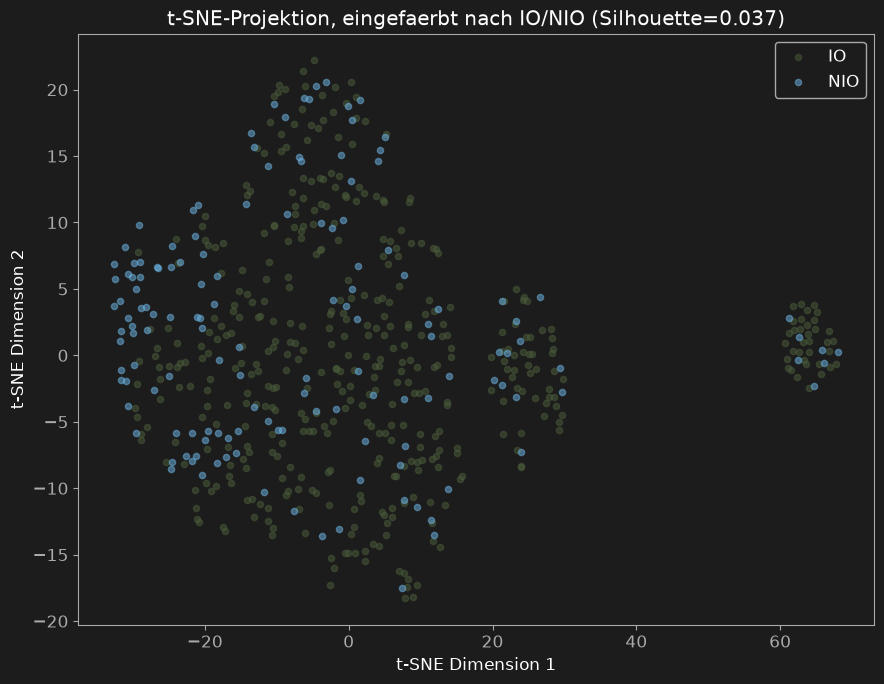

In [16]:
# =============================================================================
# Zelle 10 – t-SNE (2D) + Silhouette-Score: IO/NIO-Klassentrennbarkeit
# =============================================================================
# t-SNE dient nur der VISUALISIERUNG (nichtlineare 2D-Projektion) - der
# Silhouette-Score wird bewusst NICHT im t-SNE-Raum berechnet, da t-SNE
# Abstaende verzerrt und keine metrisch verlaessliche Grundlage bietet.
# Stattdessen: Silhouette-Score auf den PCA-Komponenten, die 92% Varianz
# erklaeren (5 Komponenten, siehe Zelle 09) - stabilere, interpretierbare
# Distanzgrundlage.
# =============================================================================

from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# --- Silhouette-Score: IO/NIO-Trennbarkeit im PCA-reduzierten Raum (92% Varianz) ---
X_pca_92 = X_pca[:, :5]  # erste 5 Komponenten, siehe Zelle 09 (92.2% kumuliert)
io_nio_numeric = (io_nio_pca == "NIO").astype(int)

sil_score = silhouette_score(X_pca_92, io_nio_numeric)
print(f"Silhouette-Score (IO/NIO, 5 PCA-Komponenten, 92% Varianz): {sil_score:.4f}")
print("Interpretation: Wertebereich -1 bis +1.")
print("  > 0.5: starke Clusterstruktur/Trennung")
print("  0.25 - 0.5: schwache bis moderate Struktur")
print("  ~ 0: ueberlappende Cluster, keine klare Trennung")
print("  < 0: Punkte im Mittel naeher am falschen Cluster als am eigenen")

# --- t-SNE 2D-Projektion (nur Visualisierung) ---
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for label, color in [("IO", COLOR_GREEN), ("NIO", COLOR_BLUE)]:
    mask = io_nio_pca == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=label, color=color, alpha=0.5, s=20)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_title(f"t-SNE-Projektion, eingefaerbt nach IO/NIO (Silhouette={sil_score:.3f})")
ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_tsne_io_nio.png")
plt.show()

Korrelation PC1 <-> rohr_dn_latent: r = 0.993
-> Hoher Betrag (nahe 1) bestaetigt: PC1 repraesentiert die latente Baugroesse.



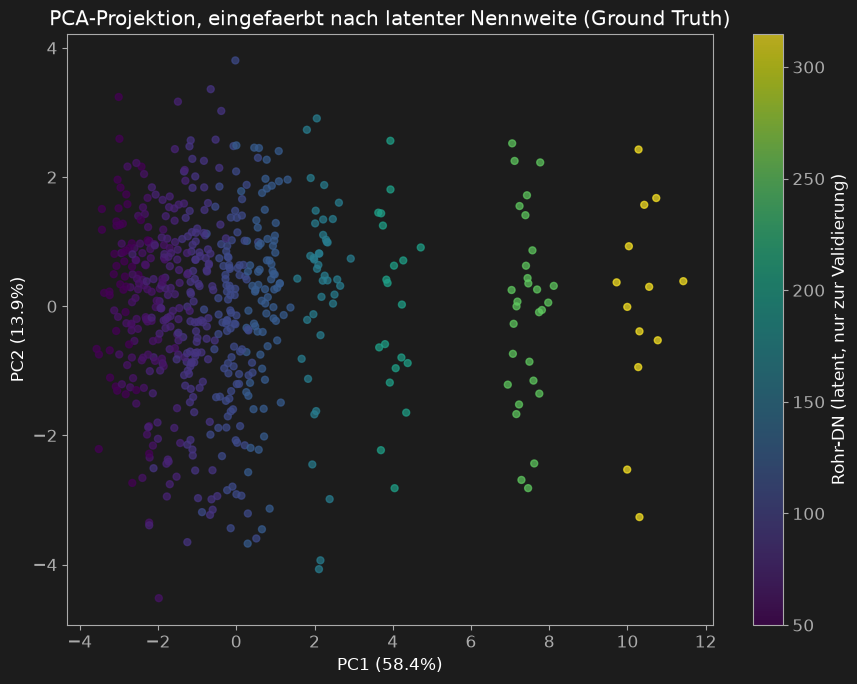

Adjusted Rand Index (KMeans-Cluster vs. tatsaechliche DN-Klassen): 0.214
Interpretation: 1.0 = perfekte Uebereinstimmung, 0.0 = Zufallsniveau, <0 = schlechter als Zufall.


In [17]:
# =============================================================================
# Zelle 11 – Ground-Truth-Validierung: PCA/Cluster-Struktur vs. rohr_dn_latent
# =============================================================================
# Ziel: Pruefen, ob die "blind" gefundene Hauptstruktur (PC1, 58.4% Varianz)
# tatsaechlich die latente Nennweite widerspiegelt. Referenzdatei wird ERST
# JETZT geladen (nicht vorher, um die EDA nicht zu beeinflussen) - reiner
# Validierungs-/Kontrollschritt nach Abschluss der blinden Analyse.
# =============================================================================

df_latent_ref = pd.read_csv("../data/raw/model_a_latent_reference.csv")
dn_latent_aligned = df_latent_ref.loc[df_pca_basis.index, "rohr_dn_latent"]

# --- Korrelation PC1 vs. latente Nennweite ---
corr_pc1_dn = np.corrcoef(X_pca[:, 0], dn_latent_aligned)[0, 1]
print(f"Korrelation PC1 <-> rohr_dn_latent: r = {corr_pc1_dn:.3f}")
print("-> Hoher Betrag (nahe 1) bestaetigt: PC1 repraesentiert die latente Baugroesse.\n")

# --- PCA-Projektion, eingefaerbt nach tatsaechlicher DN (Ground Truth) ---
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=dn_latent_aligned, cmap="viridis", alpha=0.7, s=25)
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_title("PCA-Projektion, eingefaerbt nach latenter Nennweite (Ground Truth)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Rohr-DN (latent, nur zur Validierung)")
plt.tight_layout()
save_figure(fig, "../reports/figures/03_eda_pca_ground_truth_dn.png")
plt.show()

# --- Zusaetzlich: unueberwachtes Clustering (KMeans) mit Anzahl DN-Klassen als k ---
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

k = dn_latent_aligned.nunique()
kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca_92)

ari = adjusted_rand_score(dn_latent_aligned, cluster_labels)
print(f"Adjusted Rand Index (KMeans-Cluster vs. tatsaechliche DN-Klassen): {ari:.3f}")
print("Interpretation: 1.0 = perfekte Uebereinstimmung, 0.0 = Zufallsniveau, <0 = schlechter als Zufall.")

In [18]:
# =============================================================================
# Zelle 11b – ARI nur mit PC1 (Vergleich zur 5-Komponenten-Variante aus Zelle 11)
# =============================================================================
# Ziel: pruefen, ob der niedrige ARI aus Zelle 11 (0.214) durch Rauschen aus
# PC2-PC5 (Material-/Prozessfuehrungs-Faktor, nicht DN-bezogen) verursacht
# wurde. Clustering hier ausschliesslich auf PC1.
# =============================================================================

kmeans_pc1 = KMeans(n_clusters=k, random_state=SEED, n_init=10)
cluster_labels_pc1 = kmeans_pc1.fit_predict(X_pca[:, :1])

ari_pc1 = adjusted_rand_score(dn_latent_aligned, cluster_labels_pc1)
print(f"Adjusted Rand Index (KMeans nur auf PC1) vs. tatsaechliche DN-Klassen: {ari_pc1:.3f}")
print(f"Vergleich: ARI mit 5 Komponenten (Zelle 11): 0.214")
print(f"Verbesserung durch Fokussierung auf PC1: {ari_pc1 - 0.214:+.3f}")

Adjusted Rand Index (KMeans nur auf PC1) vs. tatsaechliche DN-Klassen: 0.694
Vergleich: ARI mit 5 Komponenten (Zelle 11): 0.214
Verbesserung durch Fokussierung auf PC1: +0.480


In [19]:
# =============================================================================
# Zelle 12 – Triviale Baseline-Klassifikatoren (untere Leistungsgrenze)
# =============================================================================
# Ziel: Referenzwerte definieren, die jedes echte Modell (Notebook 05)
# schlagen muss. Baselines nutzen KEINE Information aus den Merkmalen -
# reine Vergleichsuntergrenze. Stratified Split, da Klassenungleichgewicht
# (73.9% IO / 26.1% NIO) besteht.
# =============================================================================

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

X_dummy = df.index.values.reshape(-1, 1)  # Platzhalter, Baselines nutzen keine Merkmale
y_dummy = (df["io_nio"] == "NIO").astype(int)

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    X_dummy, y_dummy, test_size=0.2, stratify=y_dummy, random_state=SEED
)

strategien = ["most_frequent", "stratified", "uniform"]
baseline_results = []

for strategie in strategien:
    dummy = DummyClassifier(strategy=strategie, random_state=SEED)
    dummy.fit(X_train_idx, y_train)
    y_pred = dummy.predict(X_test_idx)

    baseline_results.append({
        "Strategie": strategie,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "F1 (NIO=1)": round(f1_score(y_test, y_pred, zero_division=0), 3),
        "Precision (NIO=1)": round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Recall (NIO=1)": round(recall_score(y_test, y_pred, zero_division=0), 3),
    })

baseline_summary = pd.DataFrame(baseline_results)
print("=== Baseline-Klassifikatoren (untere Leistungsgrenze fuer Modell A) ===")
print(baseline_summary.to_string(index=False))
print(f"\nTest-Set NIO-Anteil: {y_test.mean()*100:.1f}%  (n={len(y_test)})")

baseline_summary.to_csv("../reports/tables/03_eda_baseline_klassifikatoren.csv", index=False)
print("\nGespeichert: reports/tables/03_eda_baseline_klassifikatoren.csv")

print("\n-> Jedes trainierte Modell (Notebook 05) muss diese Werte deutlich")
print("   uebertreffen, um als sinnvoll zu gelten. 'most_frequent' liefert")
print("   bei Klassenungleichgewicht hohe Accuracy trotz Nutzlosigkeit -")
print("   Grund, warum Accuracy allein als Metrik unzureichend ist.")

=== Baseline-Klassifikatoren (untere Leistungsgrenze fuer Modell A) ===
    Strategie  Accuracy  F1 (NIO=1)  Precision (NIO=1)  Recall (NIO=1)
most_frequent     0.736       0.000              0.000           0.000
   stratified     0.571       0.189              0.189           0.189
      uniform     0.471       0.351              0.260           0.541

Test-Set NIO-Anteil: 26.4%  (n=140)

Gespeichert: reports/tables/03_eda_baseline_klassifikatoren.csv

-> Jedes trainierte Modell (Notebook 05) muss diese Werte deutlich
   uebertreffen, um als sinnvoll zu gelten. 'most_frequent' liefert
   bei Klassenungleichgewicht hohe Accuracy trotz Nutzlosigkeit -
   Grund, warum Accuracy allein als Metrik unzureichend ist.


## Notebook 03 – Abschluss: EDA Modell A

### Durchgefuehrte Schritte
| Zelle | Inhalt | Status |
|---|---|---|
| 01-02 | Setup, Datenwoerterbuch | Erledigt |
| 03 | Struktur-Check | Erledigt |
| 04 | Missing-Value-Muster (MCAR/MNAR) | Erledigt |
| 05 | Klassenbalance, kategoriale Merkmale (Shannon-Entropie) | Erledigt |
| 06-06b | Univariate Analyse (Skewness/Kurtosis/Shapiro), Histogramme | Erledigt |
| 07-07b | Boxplots IO/NIO, Kruskal-Wallis-Test | Erledigt |
| 08-08b | Korrelationsmatrix, Vertiefung Kalibrierdruck-Regime | Erledigt |
| 09-09c | PCA, Loadings, vertiefte Missing-Value-Analyse | Erledigt |
| 10 | t-SNE + Silhouette-Score | Erledigt |
| 11-11b | Ground-Truth-Validierung gegen latente DN-Referenz | Erledigt |
| 12 | Baseline-Klassifikatoren | Erledigt |

### Zentrale Erkenntnisse

**Datenqualitaet:**
- 0 exakte Duplikate, 0 X-Konflikte (keine identischen Prozessparameter mit widerspruechlichem IO/NIO-Label)
- Delamination: 73.4% fehlend, vollstaendig MNAR erklaerbar durch wandtyp (100% Uebereinstimmung)
- 4 weitere Spalten: ~4.3% MCAR-Luecken je Spalte, empirisch bestaetigt (beobachtete vs. erwartete Kombinationsquote nahezu identisch, keine Ko-Auftretens-Haeufung)
- WICHTIG fuer Notebook 04: dropna() fuehrt zu 16.3% Zeilenverlust - fuer finale Modellierung ungeeignet, Imputation methodisch gut begruendbar (MCAR, kein Verzerrungsrisiko)

**Zwei waehrend der EDA aufgedeckte Root-Cause-Fehler in Notebook 02:**
- Vakuum-Mechanismus faelschlich fuer den gesamten DN-Bereich angenommen (korrigiert: Formluft/Vakuum-Unterscheidung ab DN200, quellenbasiert)
- Drei Formeln (wandstaerke_ideal, massedurchsatz, abzugsgeschwindigkeit) bei DN>200 vollstaendig gesaettigt (bis 100% Clipping) - durch systematischen Formel-Check aufgedeckt und behoben
- Methodische Lehre: eine nachtraegliche Erweiterung eines latenten Wertebereichs erfordert systematische Neuvalidierung ALLER abhaengigen Formeln, siehe generation_summary.md

**Klassenbalance:** IO 73.9% / NIO 26.1% - moderates Ungleichgewicht, Stratified-Split/-CV in Notebook 05 erforderlich.

**Multikollinearitaet:** Sehr hohe Korrelationen (r>0.9) zwischen den meisten geometrie-/prozessbezogenen Merkmalen. PCA bestaetigt: ~5 effektive Dimensionen statt 14 (92% Varianz). PC1 (58.4%) entspricht nachweislich der latenten Nennweite (Ground-Truth-Validierung: r=0.993, ARI=0.694 bei PC1-Clustering).

**Klassentrennbarkeit IO/NIO:** Silhouette-Score nahe 0 (0.037) - keine klare Cluster-Trennung im Merkmalsraum. Konsistent mit Generierungsdesign: NIO entsteht durch LOKALE Abweichungen vom DN-spezifischen Sollwert, nicht durch die Baugroesse selbst. Konsequenz: Modell A wird vermutlich moderate, nicht sehr hohe Trennschaerfe erreichen (realistischer Bayes-Error-Bereich erwartet).

**Statistische Signalstaerke (Kruskal-Wallis):** 10 von 14 Merkmalen signifikant unterschiedlich zwischen IO/NIO (nach Fehlerkorrektur; vorher nur 1 von 14). Diese 10 Merkmale sind stark untereinander korreliert (keine 10 unabhaengigen Signale).

**Baseline-Referenzwerte fuer Notebook 05:** most_frequent F1=0.000 (73.6% Accuracy, aber nutzlos), uniform F1=0.351 (Precision 0.260, Recall 0.541). Jedes trainierte Modell muss diese Werte deutlich uebertreffen.

### Konsequenzen fuer Notebook 04 (Preprocessing)
- Imputationsstrategie fuer 4 MCAR-Spalten erforderlich (empirisch abgesichert)
- Delamination: gesonderte Behandlung noetig (nicht imputieren, MNAR)
- Feature Engineering pruefen: DN-relative Abweichungs-Features (z. B. wandstaerke_abweichung_relativ) koennten aussagekraeftiger sein als Rohwerte, da NIO primaer durch lokale Abweichungen entsteht, nicht durch die dominante PC1-Baugroessen-Struktur
- Skalierung fuer lineare Modelle relevant (die meisten Merkmale nicht normalverteilt)
- Stratified Split/CV wegen Klassenungleichgewicht (73.9%/26.1%)

### Bekannte Limitationen
- Wellgeometrie-Sollformeln weiterhin unbelegte Annahme (siehe generation_summary.md)
- Fehlermechanismen (Bindenaehte/Blasenbildung/Risse-Schwellenwerte) plausibilisierte Annahmen
- Silhouette-Score/ARI beziehen sich auf den PCA-reduzierten Raum (92% Varianz) - Restinformation in PC6+ nicht beruecksichtigt (bewusste Vereinfachung fuer Interpretierbarkeit)

### Naechster Schritt
Notebook 04: Preprocessing Modell A (Imputation, Encoding, Feature Engineering, Skalierung), datengetrieben basierend auf den obigen Erkenntnissen.